# Benchmark v5 — GPU — Lipophilicity — scaffold split, seed 1

**Task:** Predict experimental logD at pH 7.4
**Size:** ~4,200 molecules
**Metric:** RMSE ↓, MAE ↓, R² ↑

**Scaffold split**, seed **1** — GIN, D-MPNN, SchNet, LSTM with Optuna HPO.

Results go to `results/seed_1/scaffold/`.


In [1]:
# NOTE: autoreload is intentionally NOT enabled. With C-extension packages
# (numpy, torch, torch_geometric) `%autoreload 2` reloads them mid-run and
# corrupts their state (numpy RecursionError / torch_geometric circular
# import). If you edit the benchmark modules, restart the kernel instead.
import os
# Avoid XGBoost/OpenMP segfaults in Jupyter on macOS (OMP Error #179).
for _omp_var in (
    "OMP_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "MKL_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS",
    "NUMEXPR_NUM_THREADS",
):
    os.environ[_omp_var] = "1"

import sys
from pathlib import Path

ROOT = Path(".").resolve()
for _ in range(6):
    if (ROOT / "mol_repr_utils.py").exists():
        break
    ROOT = ROOT.parent
else:
    raise FileNotFoundError("Could not find benchmark_v5 root (mol_repr_utils.py)")
sys.path.insert(0, str(ROOT))

from mol_repr_utils import *
from split_utils import (
    get_or_create_splits, subset_array, subset_list, subset_graphs_by_valid_idx,
    check_split_proportions,
)
from conformer_generation import load_conformer_graphs
from hpo_utils import (
    hpo_tabular, hpo_gnn, hpo_schnet, hpo_lstm,
    save_hpo_params, hpo_params_path,
)
from hpo_config import SKLEARN_HPO_N_ITER

DATA_DIR = ROOT / "data"

DEVICE = get_device()
print(f"Benchmark v5 (GPU) code root: {ROOT}")
print(f"Device: {DEVICE}")
print("Result paths are set in the next cell from SPLIT_SEED / SPLIT_MODE.")


INFO | Using device: cpu (request a GPU node on the cluster for large GNN/LSTM jobs)


Benchmark v5 (GPU) code root: /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5
Device: cpu
Result paths are set in the next cell from SPLIT_SEED / SPLIT_MODE.


In [2]:
DATASET_SLUG = "lipophilicity"
TASK_TYPE = "regression"
OUT_CHANNELS = 1
BATCH_SIZE = 64
GNN_EPOCHS = 100
LSTM_EPOCHS = 100
TOX21_TABULAR = False

HPO_EPOCHS = 80  # Optuna trial length; GNN_EPOCHS for final refit
HPO_N_TRIALS = 10
print(f"GPU HPO tier: large — {HPO_N_TRIALS} trials, {HPO_EPOCHS} epochs/trial, batch={BATCH_SIZE}")

SPLIT_MODE = "scaffold"   # "scaffold" or "random"
SPLIT_SEED = 1

RESULTS_ROOT = ROOT / "results" / f"seed_{SPLIT_SEED}" / SPLIT_MODE
RESULTS_DIR = RESULTS_ROOT / "gpu"
SPLITS_DIR = RESULTS_ROOT / "splits"
HPO_DIR = RESULTS_DIR / "hpo"
HISTORY_DIR = RESULTS_DIR / "histories"
for d in (RESULTS_DIR, SPLITS_DIR, HPO_DIR, HISTORY_DIR):
    d.mkdir(parents=True, exist_ok=True)
print(f"Results → {RESULTS_ROOT}")

PARTIAL_PATH = RESULTS_DIR / f"{DATASET_SLUG}_partial.json"
FRESH_RUN = False
HPO_N_ITER = SKLEARN_HPO_N_ITER

if FRESH_RUN:
    reset_dataset_run(
        DATASET_SLUG, RESULTS_DIR,
        results_root=RESULTS_ROOT, split_mode=SPLIT_MODE,
    )
    print("Fresh run — cleared partial results and splits.")

results = load_partial_results(PARTIAL_PATH)
if results:
    print(f"Resuming {len(results)} saved model(s): {', '.join(order_results(results).keys())}")
print(f"SPLIT_SEED={SPLIT_SEED}  mode={SPLIT_MODE}")


GPU HPO tier: large — 10 trials, 80 epochs/trial, batch=64
Results → /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_1/scaffold
SPLIT_SEED=1  mode=scaffold


### Load data


In [3]:
import numpy as np
import pandas as pd

df = load_dataset("lipophilicity", cache_dir=DATA_DIR)
smiles, y = preprocess_dataset(df, "lipophilicity")
print(f"Molecules : {len(smiles)}")
print(f"Target    : [{y.min():.2f}, {y.max():.2f}]  mean={y.mean():.2f}")
smiles, y = filter_bonded_molecules(smiles, y)
print(f'After bond filter: {len(smiles)} molecules')


INFO | Loading 'lipophilicity' from cache: /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/data/lipophilicity.csv
INFO | [lipophilicity] 4200 / 4200 valid molecules


Molecules : 4200
Target    : [-1.50, 4.50]  mean=2.19
After bond filter: 4200 molecules


### Representations & scaffold split


In [4]:
graphs2d_all = smiles_to_graphs(smiles, y)
graphs_dmpnn_all = smiles_to_dmpnn_graphs(smiles, y)
X_tok_all, vocab = tokenize_smiles(smiles)

graphs3d_all, valid_idx_3d, _ = load_conformer_graphs(
    DATASET_SLUG, data_dir=DATA_DIR, n_confs=25
)
graphs3d_all = ensure_atomic_numbers_list(graphs3d_all)
print(f"3D graphs loaded: {len(graphs3d_all)} / {len(smiles)} (valid_idx mapping)")

split_data = get_or_create_splits(
    smiles, RESULTS_ROOT, DATASET_SLUG,
    mode=SPLIT_MODE, seed=SPLIT_SEED, force=FRESH_RUN,
)
train_idx = split_data["train_idx"]
val_idx = split_data["val_idx"]
test_idx = split_data["test_idx"]
check_split_proportions(train_idx, val_idx, test_idx, raise_on_fail=True)
print(split_data["summary"])

tr2d = subset_list(graphs2d_all, train_idx)
va2d = subset_list(graphs2d_all, val_idx)
te2d = subset_list(graphs2d_all, test_idx)

tr_dmpnn = subset_list(graphs_dmpnn_all, train_idx)
va_dmpnn = subset_list(graphs_dmpnn_all, val_idx)
te_dmpnn = subset_list(graphs_dmpnn_all, test_idx)

tr3d = subset_graphs_by_valid_idx(graphs3d_all, valid_idx_3d, train_idx)
va3d = subset_graphs_by_valid_idx(graphs3d_all, valid_idx_3d, val_idx)
te3d = subset_graphs_by_valid_idx(graphs3d_all, valid_idx_3d, test_idx)

tr_ds = SMILESDataset(subset_array(X_tok_all, train_idx), subset_array(y, train_idx))
va_ds = SMILESDataset(subset_array(X_tok_all, val_idx), subset_array(y, val_idx))
te_ds = SMILESDataset(subset_array(X_tok_all, test_idx), subset_array(y, test_idx))


INFO | Loaded 4200 / 4200 graphs from /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/data/lipophilicity_conformers_n25.pkl  (n_confs=25)
INFO | Loaded splits from /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_1/scaffold/splits/lipophilicity_scaffold_splits.pkl


3D graphs loaded: 4200 / 4200 (valid_idx mapping)
{'n_total': 4200, 'n_train': 3360, 'n_val': 420, 'n_test': 420, 'n_scaffolds_total': 2408, 'n_scaffolds_train': 1568, 'n_scaffolds_val': 420, 'n_scaffolds_test': 420}


### GIN (2D)


In [5]:
MODEL_KEY = "GIN (2D)"
tr = tr3d if "2D" == "3D" else tr2d
va = va3d if "2D" == "3D" else va2d
te = te3d if "2D" == "3D" else te2d
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_gnn(
        tr, va, TASK_TYPE, "GIN", "2D", OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import eval_gnn, PyGLoader, build_gnn, train_gnn
    model = build_gnn("GIN", "2D", OUT_CHANNELS,
                      hidden=best["hidden"], num_layers=best["num_layers"], dropout=best["dropout"])
    train_gnn(model, tr, va, TASK_TYPE, epochs=GNN_EPOCHS, lr=best["lr"],
              batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    test_metrics = eval_gnn(model, PyGLoader(te, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    hist_name = "GIN (2D)".replace(" ", "_").replace("(", "").replace(")", "")
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_{hist_name}.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | GIN 2D — starting trial 1/10 (layers=3, hidden=192)


→ GIN (2D) (Optuna 10 trials, scaffold split) …


INFO | HPO epoch   1/80 | loss=3.7120 | val={'RMSE': 1.1251694176809304, 'MAE': 0.9243386286798687, 'R2': 0.09723954888123432}
INFO | HPO epoch   5/80 | loss=0.8083 | val={'RMSE': 0.8665779922379432, 'MAE': 0.6967527725245981, 'R2': 0.4645092209574756}
INFO | HPO epoch  10/80 | loss=0.6427 | val={'RMSE': 0.8455652620377061, 'MAE': 0.6705720678060537, 'R2': 0.4901634678126705}
INFO | HPO epoch  15/80 | loss=0.6068 | val={'RMSE': 0.7319500802739591, 'MAE': 0.5799862245896032, 'R2': 0.6179681148665523}
INFO | HPO epoch  20/80 | loss=0.5179 | val={'RMSE': 0.6982779710257607, 'MAE': 0.5488465524677719, 'R2': 0.6523090644125956}
INFO | HPO epoch  25/80 | loss=0.4633 | val={'RMSE': 0.7378233556881226, 'MAE': 0.5751772525055068, 'R2': 0.611812556601478}
INFO | HPO epoch  30/80 | loss=0.4620 | val={'RMSE': 0.6835054014581704, 'MAE': 0.5357678375694723, 'R2': 0.6668647508793596}
INFO | HPO epoch  35/80 | loss=0.4122 | val={'RMSE': 0.6816809200584562, 'MAE': 0.5352343860392769, 'R2': 0.6686408534

   scaffold test: {'RMSE': 0.7153507023185637, 'MAE': 0.5489539223989206, 'R2': 0.6154464495961018}


### D-MPNN (2D)
Bond-centric directed MPNN (Yang et al. 2019).


In [6]:
MODEL_KEY = "D-MPNN (2D)"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_gnn(
        tr_dmpnn, va_dmpnn, TASK_TYPE, "DMPNN", "2D", OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import eval_gnn, PyGLoader, build_gnn, train_gnn
    model = build_gnn("DMPNN", "2D", OUT_CHANNELS,
                      hidden=best["hidden"], num_layers=best["num_layers"], dropout=best["dropout"])
    train_gnn(model, tr_dmpnn, va_dmpnn, TASK_TYPE, epochs=GNN_EPOCHS, lr=best["lr"],
              batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    test_metrics = eval_gnn(model, PyGLoader(te_dmpnn, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_dmpnn.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | DMPNN 2D — starting trial 1/10 (layers=3, hidden=192)


→ D-MPNN (2D) (Optuna 10 trials, scaffold split) …


INFO | HPO epoch   1/80 | loss=3.3991 | val={'RMSE': 1.1239425367458729, 'MAE': 0.9135108449363283, 'R2': 0.09920720942814443}
INFO | HPO epoch   5/80 | loss=1.0514 | val={'RMSE': 0.9777468361922816, 'MAE': 0.7977285175539908, 'R2': 0.3183059166090273}
INFO | HPO epoch  10/80 | loss=0.7264 | val={'RMSE': 0.8485444057358398, 'MAE': 0.6878695903523337, 'R2': 0.48656456881340426}
INFO | HPO epoch  15/80 | loss=0.5780 | val={'RMSE': 0.7833321812165916, 'MAE': 0.6274848634554516, 'R2': 0.5624490575762635}
INFO | HPO epoch  20/80 | loss=0.5368 | val={'RMSE': 0.7345735012898572, 'MAE': 0.5918962113736641, 'R2': 0.6152246858352467}
INFO | HPO epoch  25/80 | loss=0.4997 | val={'RMSE': 0.7095475645415172, 'MAE': 0.56803873286006, 'R2': 0.6409956479081403}
INFO | HPO epoch  30/80 | loss=0.4721 | val={'RMSE': 0.7244674998477656, 'MAE': 0.5596663238924174, 'R2': 0.6257390626742466}
INFO | HPO epoch  35/80 | loss=0.4252 | val={'RMSE': 0.6767999969430517, 'MAE': 0.5348500707319804, 'R2': 0.6733690138

   scaffold test: {'RMSE': 0.7103495727927517, 'MAE': 0.5281777037263271, 'R2': 0.6208046030287928}


### GIN (3D)


In [7]:
MODEL_KEY = "GIN (3D)"
tr = tr3d if "3D" == "3D" else tr2d
va = va3d if "3D" == "3D" else va2d
te = te3d if "3D" == "3D" else te2d
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_gnn(
        tr, va, TASK_TYPE, "GIN", "3D", OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import eval_gnn, PyGLoader, build_gnn, train_gnn
    model = build_gnn("GIN", "3D", OUT_CHANNELS,
                      hidden=best["hidden"], num_layers=best["num_layers"], dropout=best["dropout"])
    train_gnn(model, tr, va, TASK_TYPE, epochs=GNN_EPOCHS, lr=best["lr"],
              batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    test_metrics = eval_gnn(model, PyGLoader(te, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    hist_name = "GIN (3D)".replace(" ", "_").replace("(", "").replace(")", "")
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_{hist_name}.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | GIN 3D — starting trial 1/10 (layers=3, hidden=192)


→ GIN (3D) (Optuna 10 trials, scaffold split) …


INFO | HPO epoch   1/80 | loss=3.3476 | val={'RMSE': 1.134060909349228, 'MAE': 0.9248006975810442, 'R2': 0.08291530122421498}
INFO | HPO epoch   5/80 | loss=1.1672 | val={'RMSE': 0.9732212115663074, 'MAE': 0.7601738367495793, 'R2': 0.32460192606565075}
INFO | HPO epoch  10/80 | loss=0.7232 | val={'RMSE': 0.9535705713875609, 'MAE': 0.7410909483564042, 'R2': 0.3516009569037887}
INFO | HPO epoch  15/80 | loss=0.5599 | val={'RMSE': 0.8703943624227334, 'MAE': 0.6769284340331242, 'R2': 0.4597822809914509}
INFO | HPO epoch  20/80 | loss=0.5239 | val={'RMSE': 0.9489852694120657, 'MAE': 0.7191062312661892, 'R2': 0.3578216967699047}
INFO | HPO epoch  25/80 | loss=0.4678 | val={'RMSE': 0.7957531593491604, 'MAE': 0.6386948878655121, 'R2': 0.548462910690915}
INFO | HPO epoch  30/80 | loss=0.4308 | val={'RMSE': 0.9704202683525985, 'MAE': 0.7512922291333477, 'R2': 0.3284839405274147}
INFO | HPO epoch  35/80 | loss=0.4001 | val={'RMSE': 0.6899841994338094, 'MAE': 0.5305951015846361, 'R2': 0.6605193874

   scaffold test: {'RMSE': 0.7255241297434066, 'MAE': 0.5479634285904467, 'R2': 0.6044307430895491}


### SchNet (3D coords)
Uses atomic numbers + xyz from min-energy n=25 conformer.


In [8]:
MODEL_KEY = "SchNet (3D coords)"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_schnet(
        tr3d, va3d, TASK_TYPE, OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import eval_schnet, PyGLoader, build_schnet, train_schnet
    model = build_schnet(
        OUT_CHANNELS,
        hidden_channels=best["hidden_channels"],
        num_filters=best["num_filters"],
        num_interactions=best["num_interactions"],
        num_gaussians=best["num_gaussians"],
        cutoff=best["cutoff"],
    )
    train_schnet(model, tr3d, va3d, TASK_TYPE, epochs=GNN_EPOCHS, lr=best["lr"],
                 batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    te3d_schnet = ensure_atomic_numbers_list(te3d)
    test_metrics = eval_schnet(model, PyGLoader(te3d_schnet, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_schnet.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | SchNet — starting trial 1/10


→ SchNet (3D coords) (Optuna 10 trials, scaffold split) …


INFO | HPO epoch   1/80 | loss=5.8831 | val={'RMSE': 1.1279081577641894, 'MAE': 0.8973307955566616, 'R2': 0.09283943771170267}
INFO | HPO epoch   5/80 | loss=1.1310 | val={'RMSE': 1.0029603558433686, 'MAE': 0.7994890006968662, 'R2': 0.28269440249118427}
INFO | HPO epoch  10/80 | loss=0.9835 | val={'RMSE': 1.1187654522234394, 'MAE': 0.8745736269457709, 'R2': 0.10748652948370696}
INFO | HPO epoch  15/80 | loss=0.8441 | val={'RMSE': 0.8931050196912916, 'MAE': 0.7218399682658769, 'R2': 0.4312233661702304}
INFO | HPO epoch  20/80 | loss=0.7048 | val={'RMSE': 0.8653610449341547, 'MAE': 0.7086698855406471, 'R2': 0.4660121589393422}
INFO | HPO epoch  25/80 | loss=0.6698 | val={'RMSE': 0.860249213247834, 'MAE': 0.6860493675672582, 'R2': 0.4723022357020449}
INFO | HPO epoch  30/80 | loss=0.6133 | val={'RMSE': 0.8548637072602522, 'MAE': 0.6981017139784637, 'R2': 0.4788887542278727}
INFO | HPO epoch  35/80 | loss=0.5684 | val={'RMSE': 0.9211691772689127, 'MAE': 0.763218866049179, 'R2': 0.394916261

   scaffold test: {'RMSE': 0.7902013023438641, 'MAE': 0.585081133241987, 'R2': 0.5307607933701142}


### SMILES LSTM
Canonical isomeric SMILES tokens.


In [9]:
MODEL_KEY = "SMILES LSTM"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_lstm(
        tr_ds, va_ds, TASK_TYPE, len(vocab), OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import SmilesLSTM, eval_lstm, TorchLoader, train_lstm
    model = SmilesLSTM(len(vocab), embed_dim=best["embed_dim"], hidden_dim=best["hidden_dim"],
                       n_layers=best["n_layers"], out_channels=OUT_CHANNELS, dropout=best["dropout"])
    train_lstm(model, tr_ds, va_ds, TASK_TYPE, epochs=LSTM_EPOCHS, lr=best["lr"],
               batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    test_metrics = eval_lstm(model, TorchLoader(te_ds, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_lstm.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | LSTM — starting trial 1/10


→ SMILES LSTM (Optuna 10 trials, scaffold split) …


INFO | HPO epoch   1/80 | loss=1.9946 | val={'RMSE': 1.1283644504391512, 'MAE': 0.9017062846837299, 'R2': 0.09210530977034326}
INFO | HPO epoch   5/80 | loss=0.9306 | val={'RMSE': 1.0408568226980723, 'MAE': 0.8208749518818443, 'R2': 0.2274640960290153}
INFO | HPO epoch  10/80 | loss=0.6402 | val={'RMSE': 0.9210917749262315, 'MAE': 0.710378616626951, 'R2': 0.3950179427528471}
INFO | HPO epoch  15/80 | loss=0.5238 | val={'RMSE': 0.8320689552656899, 'MAE': 0.6446965914796151, 'R2': 0.5063088712942541}
INFO | HPO epoch  20/80 | loss=0.4274 | val={'RMSE': 0.8350938173414107, 'MAE': 0.6290404423583477, 'R2': 0.5027128664593147}
INFO | HPO epoch  25/80 | loss=0.3559 | val={'RMSE': 0.7910067487766648, 'MAE': 0.6032238783847008, 'R2': 0.553833391976464}
INFO | HPO epoch  30/80 | loss=0.3211 | val={'RMSE': 0.7736315254196319, 'MAE': 0.5834952925376239, 'R2': 0.573219071633601}
INFO | HPO epoch  35/80 | loss=0.2617 | val={'RMSE': 0.777826353855068, 'MAE': 0.5949814283510759, 'R2': 0.5685782927253

   scaffold test: {'RMSE': 0.7871679236167072, 'MAE': 0.6114621118952831, 'R2': 0.5343564549529932}


### Finalize GPU + merge


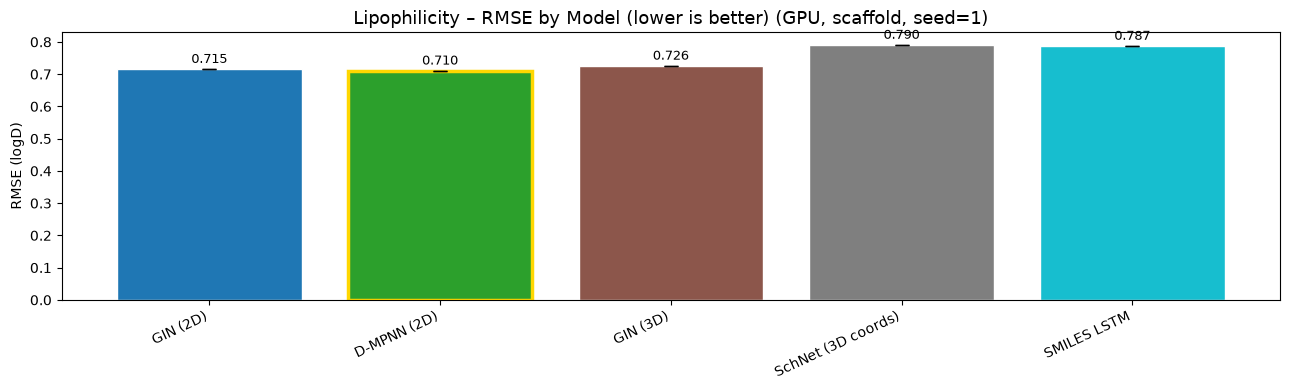

=== LIPOPHILICITY Results (5/12 models) ===
                               RMSE              MAE               R2
Model                                                                
GIN (2D)            0.7154 ± 0.0000  0.5490 ± 0.0000  0.6154 ± 0.0000
D-MPNN (2D)         0.7103 ± 0.0000  0.5282 ± 0.0000  0.6208 ± 0.0000
GIN (3D)            0.7255 ± 0.0000  0.5480 ± 0.0000  0.6044 ± 0.0000
SchNet (3D coords)  0.7902 ± 0.0000  0.5851 ± 0.0000  0.5308 ± 0.0000
SMILES LSTM         0.7872 ± 0.0000  0.6115 ± 0.0000  0.5344 ± 0.0000

Final CSV : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_1/scaffold/gpu/lipophilicity_results.csv
Plot      : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_1/scaffold/gpu/lipophilicity_rmse_comparison.png
Partial   : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_p

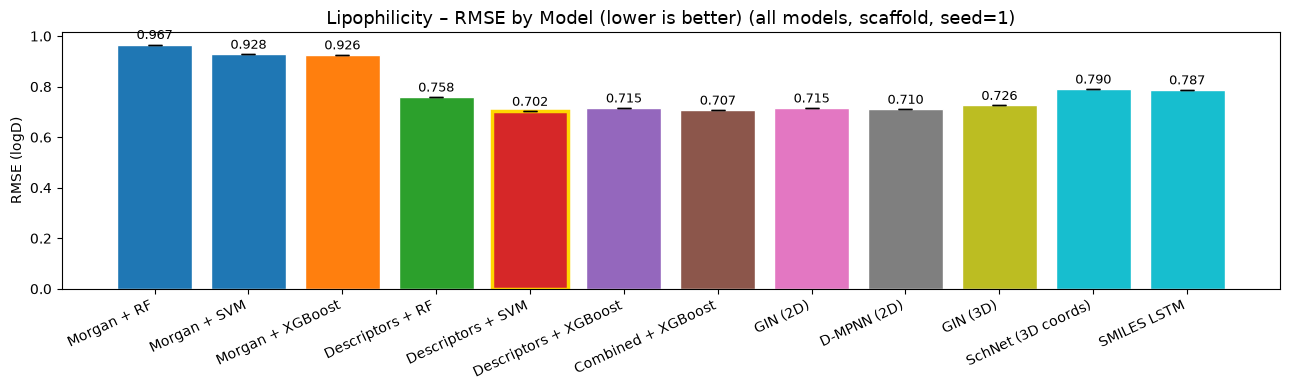

=== LIPOPHILICITY Results (12/12 models) ===
                                  RMSE              MAE               R2
Model                                                                   
Morgan + RF            0.9666 ± 0.0000  0.7593 ± 0.0000  0.2978 ± 0.0000
Morgan + SVM           0.9281 ± 0.0000  0.7297 ± 0.0000  0.3528 ± 0.0000
Morgan + XGBoost       0.9257 ± 0.0000  0.7329 ± 0.0000  0.3561 ± 0.0000
Descriptors + RF       0.7585 ± 0.0000  0.5955 ± 0.0000  0.5677 ± 0.0000
Descriptors + SVM      0.7022 ± 0.0000  0.5333 ± 0.0000  0.6294 ± 0.0000
Descriptors + XGBoost  0.7154 ± 0.0000  0.5543 ± 0.0000  0.6154 ± 0.0000
Combined + XGBoost     0.7069 ± 0.0000  0.5533 ± 0.0000  0.6245 ± 0.0000
GIN (2D)               0.7154 ± 0.0000  0.5490 ± 0.0000  0.6154 ± 0.0000
D-MPNN (2D)            0.7103 ± 0.0000  0.5282 ± 0.0000  0.6208 ± 0.0000
GIN (3D)               0.7255 ± 0.0000  0.5480 ± 0.0000  0.6044 ± 0.0000
SchNet (3D coords)     0.7902 ± 0.0000  0.5851 ± 0.0000  0.5308 ± 0.0000
SMILES

In [10]:
finalize_dataset_results(DATASET_SLUG, PARTIAL_PATH, RESULTS_DIR, TASK_TYPE,
    plot_title=f"Lipophilicity – RMSE by Model (lower is better) (GPU, {SPLIT_MODE}, seed={SPLIT_SEED})", ylabel="RMSE (logD)", minimize=True)
cpu_partial = RESULTS_ROOT / "cpu" / f"{DATASET_SLUG}_partial.json"
if cpu_partial.exists():
    merge_combined_results(DATASET_SLUG, cpu_partial, PARTIAL_PATH, RESULTS_ROOT / "combined",
        TASK_TYPE, plot_title=f"Lipophilicity – RMSE by Model (lower is better) (all models, {SPLIT_MODE}, seed={SPLIT_SEED})", ylabel="RMSE (logD)", minimize=True)
else:
    print("Run CPU notebook first for combined results.")
